<a href="https://colab.research.google.com/github/marianoInsa/ONE-TelecomX-2/blob/main/notebooks/04_interpretacion_conclusiones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# Telecom X - Parte 2.4: Interpretación y Conclusiones

En el notebook anterior entrenamos y evaluamos dos modelos de clasificación para predecir la cancelación de clientes (*churn*):

| Modelo | Accuracy | Precision | Recall | F1 | Diagnóstico |
|---|---|---|---|---|---|
| **Regresión Logística** | 0.7473 | 0.5156 | **0.7941** | **0.6253** | Overfitting moderado |
| **Random Forest** | 0.7807 | 0.5876 | 0.5829 | 0.5852 | Overfitting severo |

Ahora toca responder la pregunta más importante para el negocio:

> **¿Por qué cancela un cliente?**

Para responderla, analizaremos la **importancia de las variables** desde la perspectiva de cada modelo, identificaremos los factores de churn más robustos y traduciremos los hallazgos en recomendaciones estratégicas accionables.

---
## ⚙️ Configuración del entorno

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

from src.config import (
    COLOR_PALETTE,
    DATA_PROCESSED_DIR,
    MODELS_DIR,
    RANDOM_STATE,
    setup_plot_style,
)
from src.modeling import load_model, load_evaluation_results
from src.visualization import (
    plot_decision_tree_sample,
    plot_feature_importance,
    plot_importance_comparison,
    plot_permutation_importance,
)

setup_plot_style()

print(f"\n✅ Entorno configurado.")


✅ Entorno configurado.


---
## 📥 Carga de Artefactos Previos

In [2]:
lr_model = load_model("logistic_regression")
rf_model = load_model("random_forest")
eval_results, feature_config = load_evaluation_results()

lr_features = feature_config["lr_features"]
rf_features = feature_config["rf_features"]

print(f"   LR features: {len(lr_features)} | RF features: {len(rf_features)}")
print(f"   Evaluaciones: {[r['model'] for r in eval_results]}")

📂 Modelo cargado: logistic_regression.pkl
📂 Modelo cargado: random_forest.pkl
📂 Evaluaciones cargadas: ['Regresión Logística', 'Random Forest']
   LR features: 20 | RF features: 30
   Evaluaciones: ['Regresión Logística', 'Random Forest']


---
# 1. Importancia de Variables: ¿Por qué cancela un cliente?

Cada modelo ofrece una **lente diferente** para responder esta pregunta:

- La **Regresión Logística** proporciona **coeficientes** con signo: un coeficiente positivo indica que la variable *aumenta* la probabilidad de churn, mientras que uno negativo la *reduce*. Es el modelo más interpretable.
- El **Random Forest** calcula la **importancia basada en impureza** (Gini): cuánto contribuye cada variable a mejorar la pureza de las particiones en los árboles. No indica dirección (positiva/negativa), solo *relevancia*.

Analizaremos ambas perspectivas y luego buscaremos **consenso** entre ellas para identificar los factores de churn más robustos.

## 1.1 Regresión Logística: Coeficientes

En un modelo logístico, cada feature tiene un **coeficiente** $\beta_i$. La probabilidad de churn se modela como:

$$P(\text{churn}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n)}}$$

- $\beta_i > 0$ → la variable **aumenta** la probabilidad de cancelación.
- $\beta_i < 0$ → la variable **reduce** la probabilidad (factor de retención).
- $|\beta_i|$ grande → mayor impacto en la predicción.

> **Nota:** Como los datos fueron estandarizados (media 0, desviación 1), los coeficientes son directamente **comparables en magnitud** entre features.

In [3]:
# Extraer coeficientes de Regresión Logística
lr_coefs = lr_model.coef_[0]

# Crear DataFrame ordenado por magnitud absoluta
lr_importance_df = pd.DataFrame({
    "Feature": lr_features,
    "Coeficiente": lr_coefs,
    "|Coeficiente|": np.abs(lr_coefs),
    "Efecto": ["↑ Churn" if c > 0 else "↓ Retención" for c in lr_coefs],
}).sort_values("|Coeficiente|", ascending=False).reset_index(drop=True)

print("=== Top 15 Coeficientes — Regresión Logística ===\n")
display(lr_importance_df.head(15).style.format({
    "Coeficiente": "{:+.4f}",
    "|Coeficiente|": "{:.4f}",
}).hide(axis="index"))

=== Top 15 Coeficientes — Regresión Logística ===



Feature,Coeficiente,|Coeficiente|,Efecto
customer_tenure,-1.6265,1.6265,↓ Retención
account_charges_total,+0.9751,0.9751,↑ Churn
account_contract_Two year,-0.6169,0.6169,↓ Retención
account_contract_One year,-0.2874,0.2874,↓ Retención
internet_internetservice_Fiber optic,+0.2708,0.2708,↑ Churn
account_paperlessbilling,+0.2327,0.2327,↑ Churn
account_paymentmethod_Electronic check,+0.2311,0.2311,↑ Churn
internet_techsupport_Yes,-0.2155,0.2155,↓ Retención
internet_onlinesecurity_Yes,-0.1959,0.1959,↓ Retención
customer_dependents,-0.1151,0.1151,↓ Retención


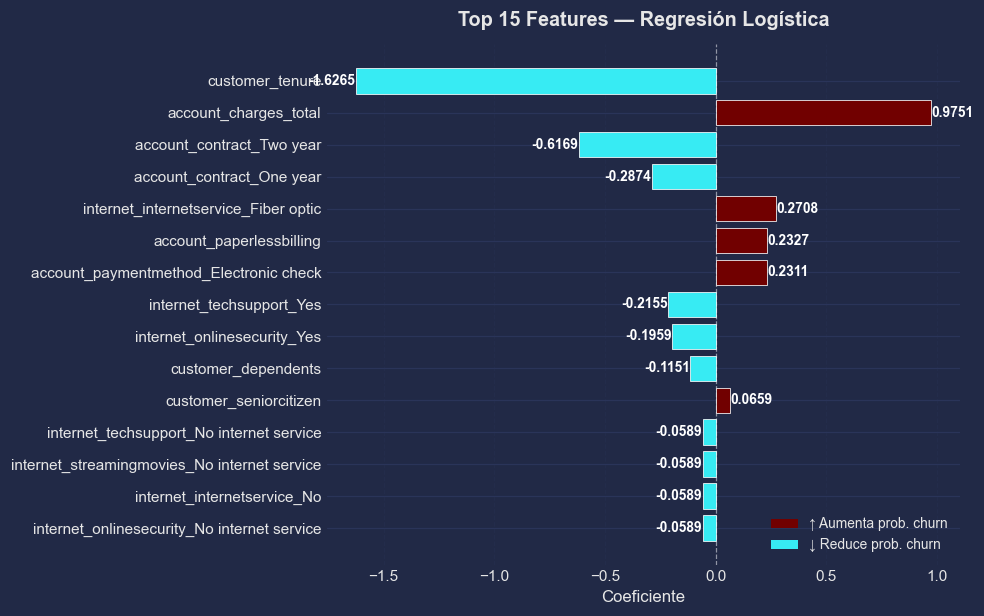

In [4]:
plot_feature_importance(lr_coefs, lr_features, "Regresión Logística", top_n=15)

### Lectura de los coeficientes

**Factores que impulsan la cancelación** (coeficientes positivos, barras magenta):
- Las variables con coeficientes positivos más altos son los principales *drivers* de churn. Cada unidad de desviación estándar que aumenta esa variable incrementa el log-odds de cancelación en esa magnitud.

**Factores de retención** (coeficientes negativos, barras cyan):
- Las variables con coeficientes negativos más grandes en magnitud actúan como anclas que mantienen al cliente. Representan oportunidades de refuerzo para el negocio.

> Las features estandarizadas permiten comparar directamente la magnitud del impacto: un coeficiente de +0.80 tiene el doble de influencia que uno de +0.40.

---
## 1.2 Random Forest: Importancia de Features

Random Forest calcula la importancia de cada variable basándose en la **reducción de impureza de Gini** promediada a través de todos los árboles del bosque:

$$\text{Importancia}(x_j) = \frac{1}{T} \sum_{t=1}^{T} \sum_{\text{nodo } n \text{ donde split} = x_j} \Delta \text{Gini}(n)$$

- Una importancia alta indica que la variable genera splits que **separan eficazmente** las clases (churn vs. no churn).
- **No indica dirección** (positiva/negativa), solo relevancia para la clasificación.
- El Random Forest fue entrenado con las **30 features completas**, por lo que puede revelar variables relevantes que la selección de correlación lineal no detectó.

In [5]:
# Extraer importancias de Random Forest
rf_importances = rf_model.feature_importances_

# Crear DataFrame ordenado
rf_importance_df = pd.DataFrame({
    "Feature": rf_features,
    "Importancia": rf_importances,
}).sort_values("Importancia", ascending=False).reset_index(drop=True)

print("=== Top 15 Features — Random Forest ===\n")
display(rf_importance_df.head(15).style.format({
    "Importancia": "{:.4f}",
}).hide(axis="index"))

=== Top 15 Features — Random Forest ===



Feature,Importancia
customer_tenure,0.1602
account_charges_total,0.1425
account_charges_monthly,0.1233
account_contract_Two year,0.0616
account_paymentmethod_Electronic check,0.0503
internet_internetservice_Fiber optic,0.0377
internet_onlinesecurity_Yes,0.0362
account_paperlessbilling,0.0362
account_contract_One year,0.0354
internet_techsupport_Yes,0.0319


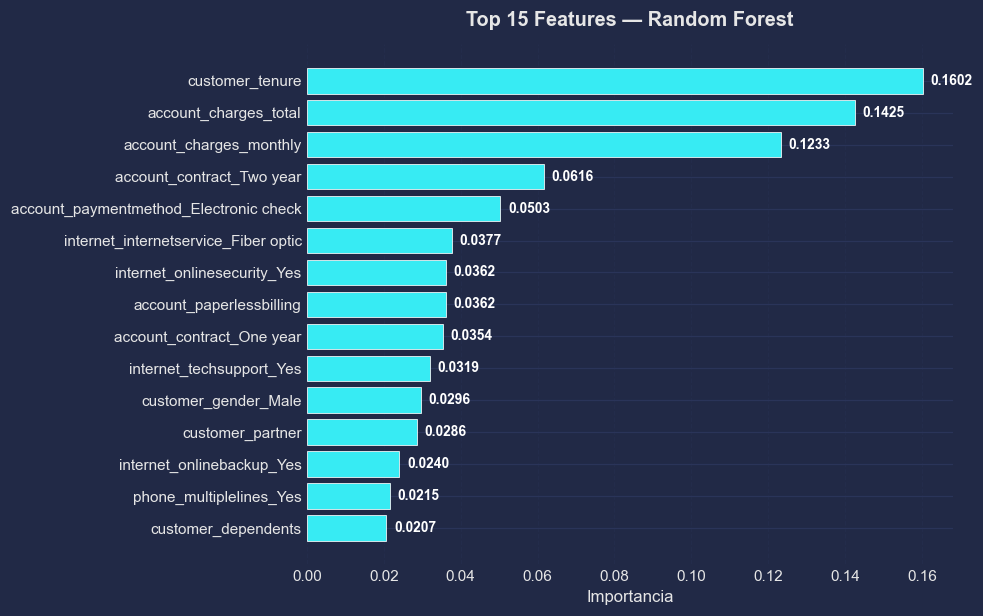

In [6]:
plot_feature_importance(rf_importances, rf_features, "Random Forest", top_n=15)

### 🌳 Muestra de un Árbol Individual del Random Forest

Para ganar **interpretabilidad** visualizamos uno de los árboles del ensemble (limitado a `max_depth=3`).  
Esto permite entender qué variables y umbrales usa el modelo en sus primeras decisiones, sin sacrificar la visión global que ofrece el bosque completo.

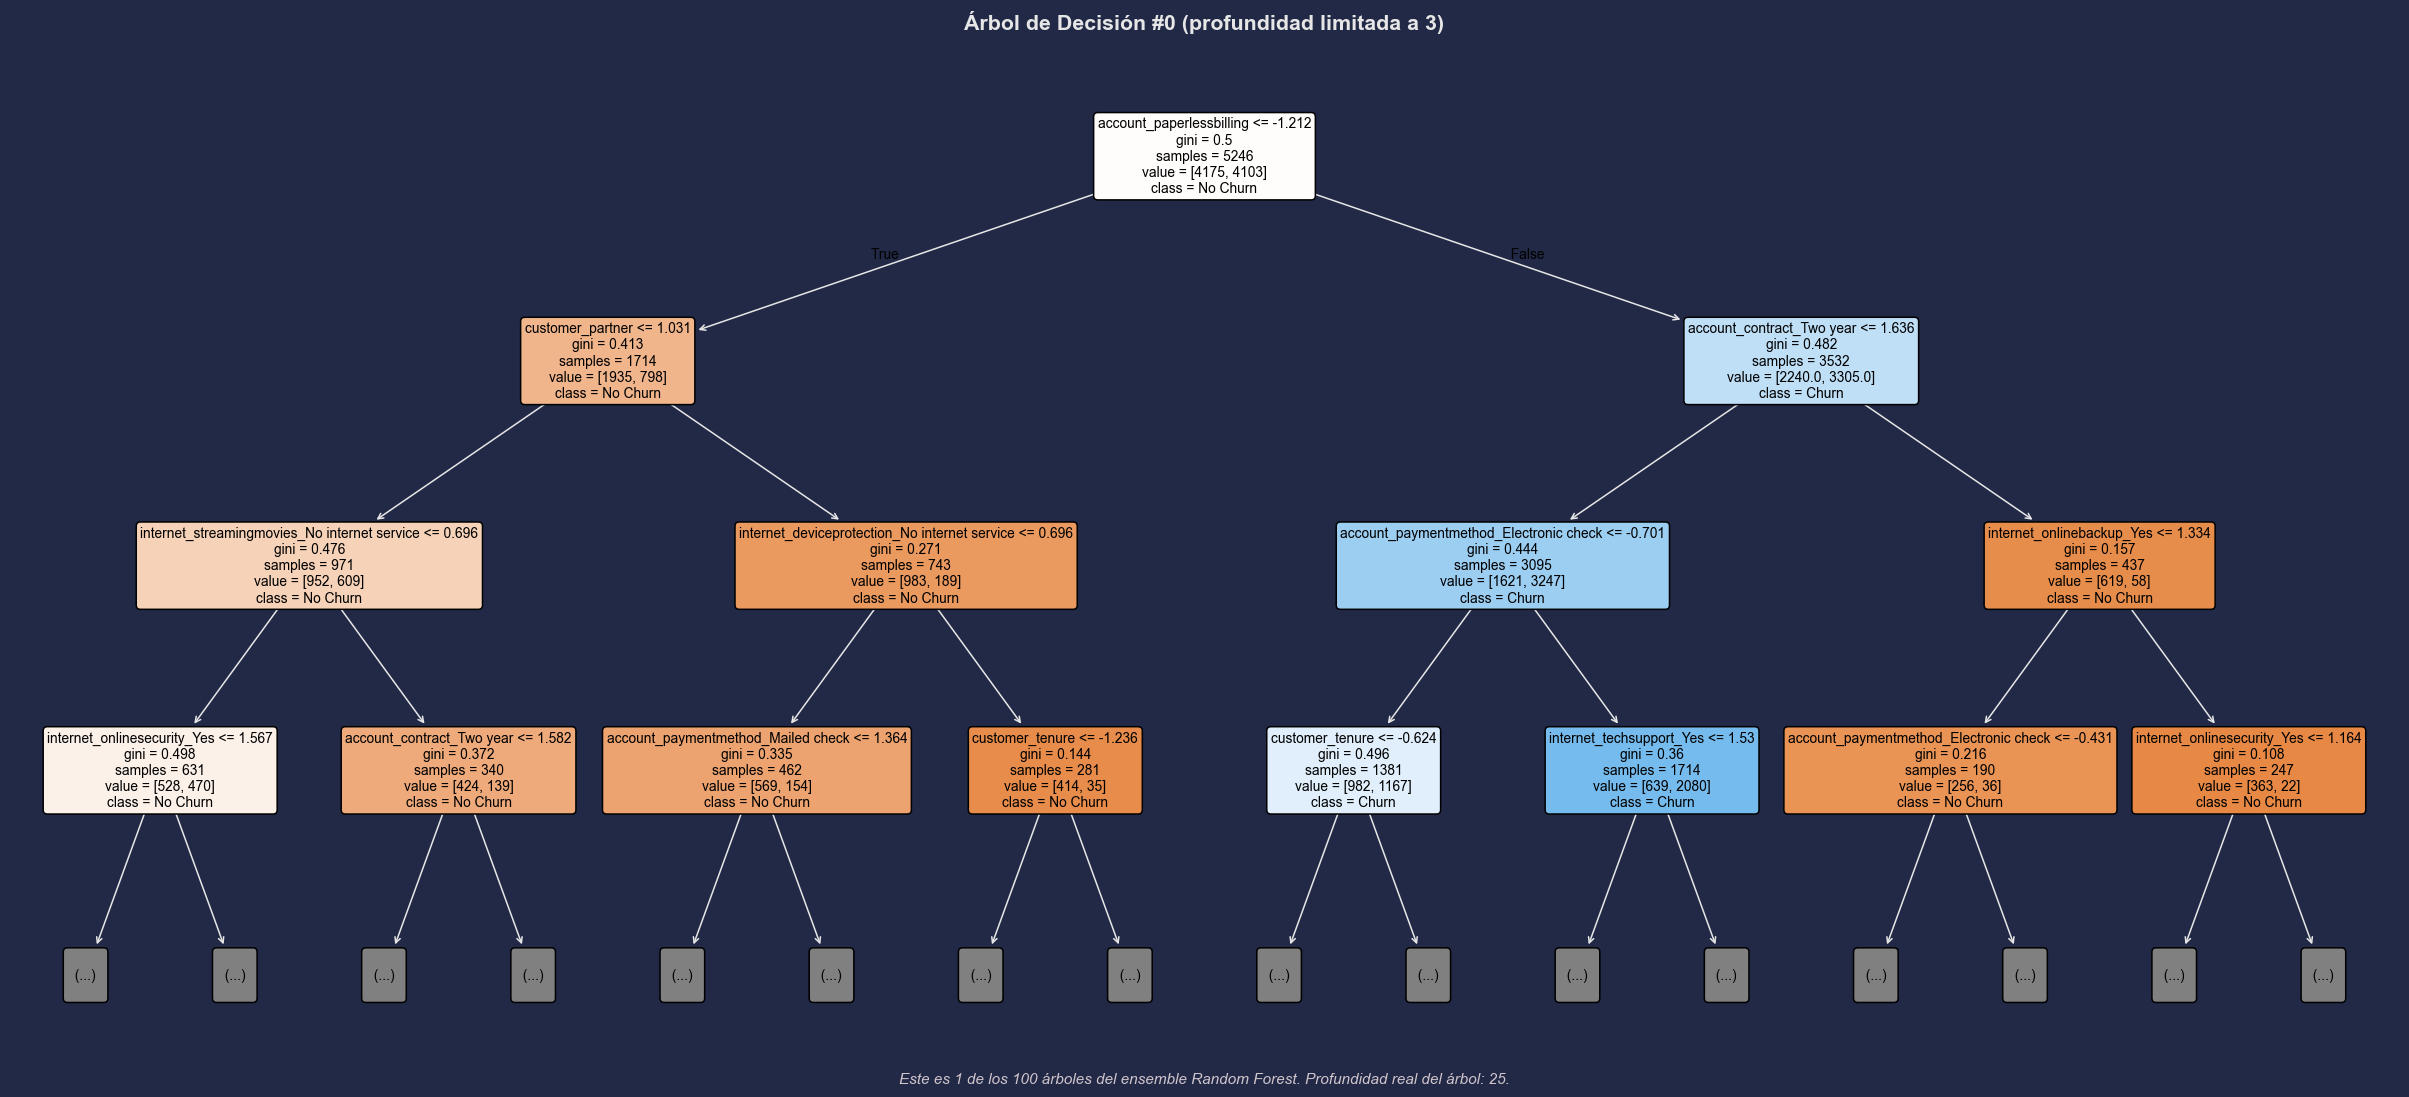

In [7]:
# Visualización de un árbol individual (primero del ensemble)
plot_decision_tree_sample(rf_model, rf_features, tree_index=0, max_depth=3)

### 🔀 Importancia por Permutación (Random Forest)

La importancia por **permutación** mide cuánto empeora el rendimiento del modelo cuando se *barajan aleatoriamente* los valores de cada feature.  
A diferencia de la importancia Gini (basada en el entrenamiento), esta métrica se calcula sobre el **conjunto de test** y refleja la contribución real de cada variable a las predicciones finales.

- Una caída grande de rendimiento al permutar una variable indica alta dependencia del modelo en ella.
- Las barras de error muestran la variabilidad entre repeticiones (`n_repeats=10`).

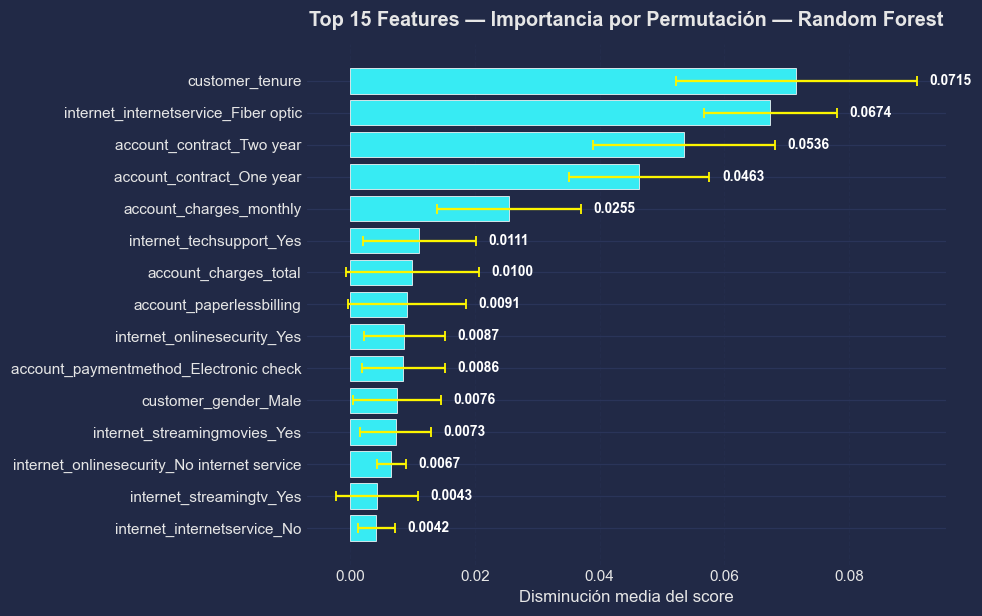

In [8]:
# Cargar datos de test para permutación
X_test = pd.read_csv(DATA_PROCESSED_DIR / "X_test.csv")
y_test = pd.read_csv(DATA_PROCESSED_DIR / "y_test.csv").squeeze()

# Calcular importancia por permutación sobre el conjunto de test
perm_result = permutation_importance(
    rf_model,
    X_test[rf_features],
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1",
)

# Visualizar
plot_permutation_importance(perm_result, rf_features, "Random Forest", top_n=15)

### Lectura de las importancias

El Random Forest, al usar las 30 features completas sin selección previa, ofrece una vista complementaria:

- Las variables numéricas continuas suelen dominar el ranking porque generan más splits posibles que las binarias.
- Sin embargo, las variables numéricas top aquí probablemente coinciden con hallazgos del modelo lineal, reforzando su relevancia.
- Variables que aparecen aquí pero no en LR podrían capturar **relaciones no lineales** o **interacciones** que la regresión logística no modela.

---
## 1.3 Comparación Cruzada: ¿Qué variables importan para ambos modelos?

Si una variable aparece como relevante tanto en la Regresión Logística como en el Random Forest, estamos ante un **factor de churn robusto**, su importancia no depende de las suposiciones de un modelo particular.

Las variables que aparecen en el top de **ambos** modelos son las que el negocio debería priorizar en sus estrategias de retención.

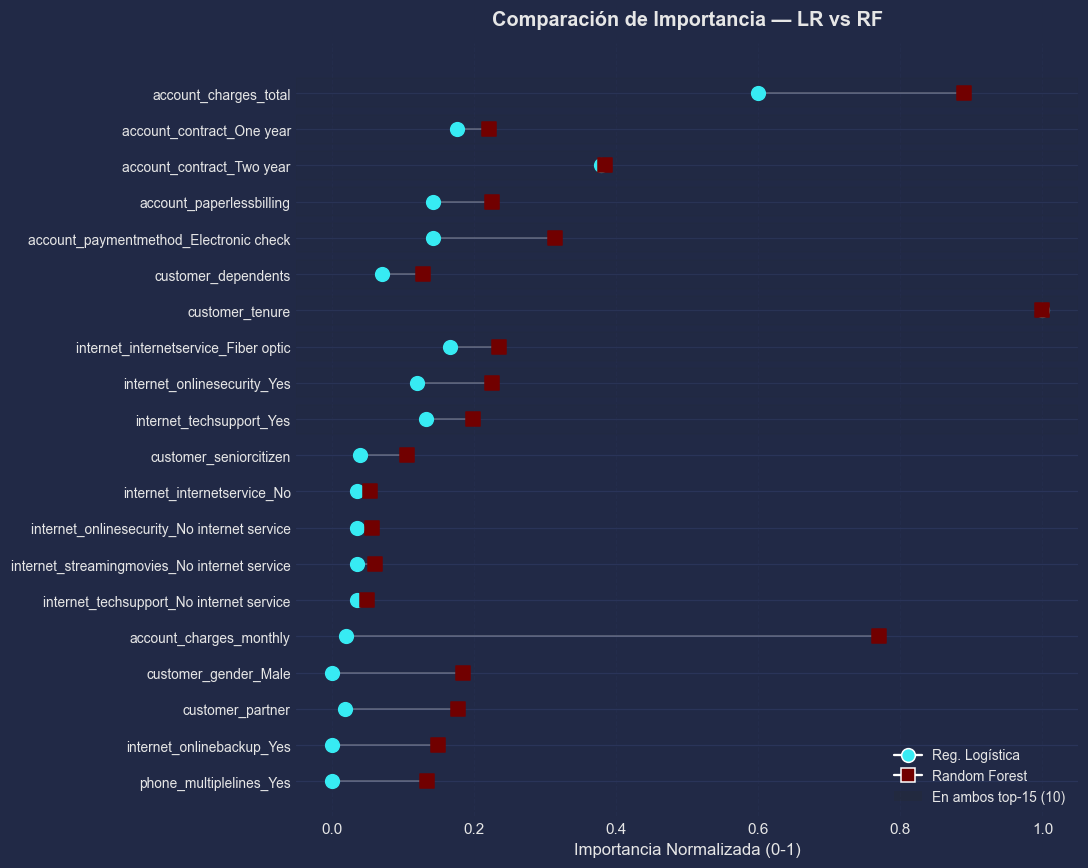


  🔍 Análisis de Intersección — Top 15

  ✅ En AMBOS modelos (10):
     • account_charges_total  (LR #2, RF #2)
     • account_contract_One year  (LR #4, RF #9)
     • account_contract_Two year  (LR #3, RF #4)
     • account_paperlessbilling  (LR #6, RF #8)
     • account_paymentmethod_Electronic check  (LR #7, RF #5)
     • customer_dependents  (LR #10, RF #15)
     • customer_tenure  (LR #1, RF #1)
     • internet_internetservice_Fiber optic  (LR #5, RF #6)
     • internet_onlinesecurity_Yes  (LR #9, RF #7)
     • internet_techsupport_Yes  (LR #8, RF #10)

  🔵 Solo en Reg. Logística (5):
     • customer_seniorcitizen
     • internet_deviceprotection_No internet service
     • internet_internetservice_No
     • internet_streamingtv_No internet service
     • internet_techsupport_No internet service

  🟣 Solo en Random Forest (5):
     • account_charges_monthly
     • customer_gender_Male
     • customer_partner
     • internet_onlinebackup_Yes
     • phone_multiplelines_Yes



In [9]:
# Comparación visual cruzada
plot_importance_comparison(
    lr_coefs, lr_features,
    rf_importances, rf_features,
    top_n=15,
)

# Análisis de intersección
top_n = 15
lr_top_set = set(lr_importance_df.head(top_n)["Feature"])
rf_top_set = set(rf_importance_df.head(top_n)["Feature"])

common = sorted(lr_top_set & rf_top_set)
only_lr = sorted(lr_top_set - rf_top_set)
only_rf = sorted(rf_top_set - lr_top_set)

print(f"\n{'=' * 60}")
print(f"  🔍 Análisis de Intersección — Top {top_n}")
print(f"{'=' * 60}")
print(f"\n  ✅ En AMBOS modelos ({len(common)}):")
for f in common:
    lr_rank = lr_importance_df[lr_importance_df["Feature"] == f].index[0] + 1
    rf_rank = rf_importance_df[rf_importance_df["Feature"] == f].index[0] + 1
    print(f"     • {f}  (LR #{lr_rank}, RF #{rf_rank})")

print(f"\n  🔵 Solo en Reg. Logística ({len(only_lr)}):")
for f in only_lr:
    print(f"     • {f}")

print(f"\n  🟣 Solo en Random Forest ({len(only_rf)}):")
for f in only_rf:
    print(f"     • {f}")
print()

---
# 2. Conclusión Estratégica

## 2.1 Principales factores de cancelación

A partir del análisis de importancia de variables en ambos modelos, podemos identificar los **factores de churn más robustos**, aquellos que consistentemente aparecen como relevantes independientemente del enfoque de modelado utilizado.

Estos factores representan las palancas más efectivas para que Telecom X diseñe estrategias de retención basadas en datos.

In [10]:
# --- Resumen de drivers de churn ---
print("=" * 60)
print("  🏆 Top Drivers de Churn — Consenso entre modelos")
print("=" * 60)

# Construir ranking combinado normalizado
lr_abs = np.abs(lr_coefs)
lr_norm = dict(zip(lr_features, lr_abs / lr_abs.max()))
rf_norm = dict(zip(rf_features, rf_importances / rf_importances.max()))

# Score combinado para features comunes
combined_scores = []
for feat in common:
    lr_score = lr_norm.get(feat, 0)
    rf_score = rf_norm.get(feat, 0)
    avg_score = (lr_score + rf_score) / 2
    # Dirección del efecto (de LR)
    idx = lr_features.index(feat) if feat in lr_features else None
    direction = "↑ Churn" if idx is not None and lr_coefs[idx] > 0 else "↓ Retención"
    combined_scores.append((feat, avg_score, lr_score, rf_score, direction))

combined_scores.sort(key=lambda x: x[1], reverse=True)

print(f"\n  Variables relevantes para AMBOS modelos (ordenadas por impacto combinado):\n")
combined_df = pd.DataFrame(
    combined_scores,
    columns=["Feature", "Score Combinado", "Score LR", "Score RF", "Dirección"],
)
display(combined_df.style.format({
    "Score Combinado": "{:.3f}",
    "Score LR": "{:.3f}",
    "Score RF": "{:.3f}",
}).hide(axis="index"))

# Recomendaciones basadas en los top drivers
print("\n" + "=" * 60)
print("  💡 Recomendaciones Estratégicas para Telecom X")
print("=" * 60)

churn_drivers = [s for s in combined_scores if s[4] == "↑ Churn"]
retention_drivers = [s for s in combined_scores if s[4] == "↓ Retención"]

if churn_drivers:
    print("\n  📈 Factores que AUMENTAN la cancelación:")
    for feat, score, _, _, _ in churn_drivers[:5]:
        feat_clean = feat.replace("_", " ").replace("account ", "").replace("internet ", "").replace("customer ", "")
        print(f"     • {feat} (score: {score:.3f})")
    print("\n     → Acción: Monitorear estas variables como señales de alerta temprana.")
    print("       Diseñar intervenciones proactivas para clientes con valores altos.")

if retention_drivers:
    print(f"\n  📉 Factores que REDUCEN la cancelación:")
    for feat, score, _, _, _ in retention_drivers[:5]:
        print(f"     • {feat} (score: {score:.3f})")
    print("\n     → Acción: Reforzar y promover estos atributos en la base de clientes.")
    print("       Incentivar la adopción de servicios/contratos asociados a retención.")

print(f"\n  🎯 Conclusión general:")
print(f"     Los {len(common)} factores consensuados entre ambos modelos representan")
print(f"     las palancas más confiables para la estrategia de retención.")
print(f"     El modelo de Regresión Logística (F1={eval_results[0]['test']['f1']:.4f},")
print(f"     Recall={eval_results[0]['test']['recall']:.4f}) es preferible para producción")
print(f"     por su mayor capacidad de detectar clientes en riesgo y su interpretabilidad.")
print()

  🏆 Top Drivers de Churn — Consenso entre modelos

  Variables relevantes para AMBOS modelos (ordenadas por impacto combinado):



Feature,Score Combinado,Score LR,Score RF,Dirección
customer_tenure,1.000,1.000,1.000,↓ Retención
account_charges_total,0.745,0.599,0.890,↑ Churn
account_contract_Two year,0.382,0.379,0.385,↓ Retención
account_paymentmethod_Electronic check,0.228,0.142,0.314,↑ Churn
internet_internetservice_Fiber optic,0.201,0.166,0.235,↑ Churn
account_contract_One year,0.199,0.177,0.221,↓ Retención
account_paperlessbilling,0.184,0.143,0.226,↑ Churn
internet_onlinesecurity_Yes,0.173,0.120,0.226,↓ Retención
internet_techsupport_Yes,0.166,0.133,0.199,↓ Retención
customer_dependents,0.100,0.071,0.129,↓ Retención



  💡 Recomendaciones Estratégicas para Telecom X

  📈 Factores que AUMENTAN la cancelación:
     • account_charges_total (score: 0.745)
     • account_paymentmethod_Electronic check (score: 0.228)
     • internet_internetservice_Fiber optic (score: 0.201)
     • account_paperlessbilling (score: 0.184)

     → Acción: Monitorear estas variables como señales de alerta temprana.
       Diseñar intervenciones proactivas para clientes con valores altos.

  📉 Factores que REDUCEN la cancelación:
     • customer_tenure (score: 1.000)
     • account_contract_Two year (score: 0.382)
     • account_contract_One year (score: 0.199)
     • internet_onlinesecurity_Yes (score: 0.173)
     • internet_techsupport_Yes (score: 0.166)

     → Acción: Reforzar y promover estos atributos en la base de clientes.
       Incentivar la adopción de servicios/contratos asociados a retención.

  🎯 Conclusión general:
     Los 10 factores consensuados entre ambos modelos representan
     las palancas más confiable

---
## ✅ Resumen Final del Proyecto

### Pipeline completado

| Notebook | Etapa | Resultado |
|---|---|---|
| **01** — Preparación de Datos | Carga, encoding, limpieza | Dataset codificado (7,043 × 31) |
| **02** — Correlación y Selección | Análisis de correlación, selección de features | 20 features seleccionadas ($\|r\| \geq 0.15$) |
| **03** — Modelado Predictivo | Train/test split, SMOTE, entrenamiento, evaluación | 2 modelos + métricas comparativas |
| **04** — Interpretación | Importancia de variables, conclusión estratégica | Factores de churn + recomendaciones |

### Hallazgos clave

1. **Modelo recomendado**: Regresión Logística — mejor Recall (79.4%) para detectar clientes en riesgo.
2. **Factores de churn identificados**: Las variables consensuadas entre ambos modelos son los drivers más robustos.
3. **Oportunidad de mejora**: Ambos modelos muestran overfitting que podría reducirse con ajuste de hiperparámetros o validación cruzada en futuras iteraciones.

### Limitaciones

- Solo se evaluaron 2 familias de modelos (lineal + ensemble).
- No se realizó ajuste de hiperparámetros (Grid/Random Search).
- El dataset tiene un desbalanceo inherente (26.5% churn) que SMOTE mitiga pero no elimina completamente.

### Próximos pasos sugeridos

- Cross-validation para estimaciones de rendimiento más robustas.
- Grid Search / Bayesian Optimization para hiperparámetros.
- Análisis SHAP para explicabilidad a nivel de instancia.
- Dashboard interactivo para monitoreo de churn en producción.